# Train TabR dari POC-ABS flatten ordered

- sumber: `output/apex/features/poc_abs_flatten_ordered.xlsx`
- semua row frame dipakai sebagai sampel
- external test: 20 `event_clip` tiap label
- output run: `output/apex/train/t1`, `t2`, dst

## v2 split lebih fair\n
\n
Internal validation di-split berdasarkan `event_clip`, bukan row frame.

In [1]:
import os
import re
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'preprocess-anxiety':
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f'Project root: {ROOT}')


Project root: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st


In [2]:
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from joblib import dump
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger

from core.data_module import TabRDataModule
from core.TabR import LitTabR


In [3]:
FEATURES_PATH = ROOT / 'output/apex/features/poc_abs_flatten_ordered.xlsx'
TRAIN_ROOT = ROOT / 'output/apex/train'
N_EXTERNAL_PER_LABEL = 20
BATCH_SIZE = 128
MAX_EPOCHS = 50
RANDOM_SEED = 42
THRESHOLD = 0.5

TRAIN_ROOT.mkdir(parents=True, exist_ok=True)
print(FEATURES_PATH)
print(TRAIN_ROOT)


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/features/poc_abs_flatten_ordered.xlsx
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train


In [4]:
def get_next_train_dir(train_root: Path) -> Path:
    existing = []
    for path in train_root.iterdir():
        if path.is_dir() and re.fullmatch(r't\d+', path.name):
            existing.append(int(path.name[1:]))
    next_idx = max(existing, default=0) + 1
    out_dir = train_root / f't{next_idx}'
    out_dir.mkdir(parents=True, exist_ok=False)
    return out_dir


def plot_lightning_metrics(metrics_csv):
    import pandas as pd
    import matplotlib.pyplot as plt

    df = pd.read_csv(metrics_csv)

    if 'epoch' not in df.columns:
        raise ValueError('Kolom epoch tidak ada')

    df_epoch = (
        df.sort_values('step')
          .groupby('epoch', as_index=False)
          .last()
    )

    plt.figure()

    if 'train_loss' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['train_loss'], label='Train Loss')

    if 'val_loss' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['val_loss'], label='Val Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()

    if 'train_acc' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['train_acc'], label='Train Accuracy')

    if 'val_acc' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['val_acc'], label='Val Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


def visualize_results(model_dir, class_names=('anxiety_rendah', 'anxiety_tinggi')):
    model_dir = str(model_dir).rstrip('/')

    cm_files = {
        'Internal': os.path.join(model_dir, 'cm_internal.png'),
        'External': os.path.join(model_dir, 'cm_external.png'),
    }

    report_files = {
        'Internal': os.path.join(model_dir, 'report_internal.csv'),
        'External': os.path.join(model_dir, 'report_external.csv'),
    }

    for name, path in cm_files.items():
        if not os.path.exists(path):
            print(f'Missing {path}')
            continue

        img = mpimg.imread(path)
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'TabR {name} Confusion Matrix')
        plt.show()

    for name, path in report_files.items():
        if not os.path.exists(path):
            print(f'Missing {path}')
            continue

        df = pd.read_csv(path, index_col=0)
        print(f'\n=== {name.upper()} CLASSIFICATION REPORT ===')
        print(df)


def evaluate_model(model, loader, threshold=0.5):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            prob = torch.softmax(logits, dim=1)[:, 1]
            preds = (prob > threshold).long()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred, average=None)

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'support': sup,
        'cm': confusion_matrix(y_true, y_pred),
        'report': classification_report(y_true, y_pred, output_dict=True),
    }


def save_confusion_matrix(cm, labels, out_path, title):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


def balance_context_by_label(X, y, max_per_class=None):
    idx0 = (y == 0).nonzero(as_tuple=True)[0]
    idx1 = (y == 1).nonzero(as_tuple=True)[0]

    n = min(len(idx0), len(idx1))
    if max_per_class is not None:
        n = min(n, max_per_class)

    idx0 = idx0[torch.randperm(len(idx0))[:n]]
    idx1 = idx1[torch.randperm(len(idx1))[:n]]

    idx = torch.cat([idx0, idx1])
    idx = idx[torch.randperm(len(idx))]
    return X[idx], y[idx]


In [5]:
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.set_float32_matmul_precision('medium')

df = pd.read_excel(FEATURES_PATH)
print(df.shape)
df[['phase', 'label', 'participant', 'clip', 'event_clip', 'frame']].head()


(57656, 405)


,phase,label,participant,clip,event_clip,frame
0,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,2
1,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,3
2,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,4
3,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,5
4,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,6


In [6]:
label_map = {
    'anxiety_rendah': 0,
    'anxiety_tinggi': 1,
}

df = df[df['label'].isin(label_map)].copy()
df['target'] = df['label'].map(label_map)
df['event_id'] = df['phase'].astype(str) + '||' + df['participant'].astype(str) + '||' + df['question'].astype(str) + '||' + df['clip'].astype(str) + '||' + df['event_clip'].astype(str)

event_table = df[['event_id', 'label', 'target', 'phase', 'participant', 'question', 'clip', 'event_clip']].drop_duplicates().reset_index(drop=True)
event_table.shape


(2763, 8)

In [7]:
def balanced_external_events(event_table: pd.DataFrame, n_per_label: int, seed: int = 42) -> set[str]:
    rng = random.Random(seed)
    selected_ids: list[str] = []

    for label_name in ['anxiety_rendah', 'anxiety_tinggi']:
        label_df = event_table[event_table['label'] == label_name].copy()
        if label_df.empty:
            continue

        picked_rows = []
        used_ids = set()

        participant_groups = []
        for participant, part_df in label_df.groupby('participant', sort=True):
            part_df = part_df.sort_values(['phase', 'question', 'clip', 'event_clip'], kind='stable')
            phase_groups = []
            for phase, phase_df in part_df.groupby('phase', sort=True):
                phase_groups.append(phase_df.to_dict('records'))
            participant_groups.append((participant, phase_groups))

        while len(picked_rows) < n_per_label:
            progress = False
            for _participant, phase_groups in participant_groups:
                for records in phase_groups:
                    while records and records[0]['event_id'] in used_ids:
                        records.pop(0)
                    if not records:
                        continue
                    row = records.pop(0)
                    picked_rows.append(row)
                    used_ids.add(row['event_id'])
                    progress = True
                    if len(picked_rows) >= n_per_label:
                        break
                if len(picked_rows) >= n_per_label:
                    break
            if not progress:
                break

        if len(picked_rows) < n_per_label:
            remaining = label_df[~label_df['event_id'].isin(used_ids)].sort_values(['participant', 'phase', 'question', 'clip', 'event_clip'], kind='stable')
            for row in remaining.to_dict('records'):
                picked_rows.append(row)
                used_ids.add(row['event_id'])
                if len(picked_rows) >= n_per_label:
                    break

        selected_ids.extend([row['event_id'] for row in picked_rows[:n_per_label]])

    return set(selected_ids)


external_event_ids = balanced_external_events(event_table, N_EXTERNAL_PER_LABEL, seed=RANDOM_SEED)
df_external = df[df['event_id'].isin(external_event_ids)].copy()
df_train_all = df[~df['event_id'].isin(external_event_ids)].copy()

print('External events:', len(external_event_ids))
print('External rows:', df_external.shape)
print('Train rows:', df_train_all.shape)
print(event_table[event_table['event_id'].isin(external_event_ids)]['label'].value_counts().to_dict())
print(event_table[event_table['event_id'].isin(external_event_ids)].groupby('label')['participant'].nunique())
print(pd.crosstab(event_table[event_table['event_id'].isin(external_event_ids)]['phase'], event_table[event_table['event_id'].isin(external_event_ids)]['label']))


External events: 40
External rows: (906, 407)
Train rows: (56750, 407)
{'anxiety_tinggi': 20, 'anxiety_rendah': 20}
label
anxiety_rendah    15
anxiety_tinggi    14
Name: participant, dtype: int64
label   anxiety_rendah  anxiety_tinggi
phase                                 
after               14               7
before               6              13


In [8]:
meta_cols = [
    'phase', 'condition', 'label', 'participant', 'participant_raw', 'question', 'question_no',
    'sample', 'clip', 'event_clip', 'event_no', 'clip_path', 'frame', 'target', 'event_id',
]
feature_cols = [c for c in df.columns if c not in meta_cols]
print('n_features =', len(feature_cols))
feature_cols[:10]


n_features = 392


['mulut_x1',
 'mulut_y1',
 'mulut_t1',
 'mulut_m1',
 'mulut_x2',
 'mulut_y2',
 'mulut_t2',
 'mulut_m2',
 'mulut_x3',
 'mulut_y3']

In [9]:
train_events = event_table[~event_table['event_id'].isin(external_event_ids)].copy()
train_event_ids, val_event_ids = train_test_split(
    train_events['event_id'],
    test_size=0.2,
    stratify=train_events['target'],
    random_state=RANDOM_SEED,
)

train_event_ids = set(train_event_ids.tolist())
val_event_ids = set(val_event_ids.tolist())

df_tr = df_train_all[df_train_all['event_id'].isin(train_event_ids)].copy()
df_val = df_train_all[df_train_all['event_id'].isin(val_event_ids)].copy()

imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_np = scaler.fit_transform(imputer.fit_transform(df_tr[feature_cols]))
X_val_np = scaler.transform(imputer.transform(df_val[feature_cols]))
X_ext_np = scaler.transform(imputer.transform(df_external[feature_cols]))

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(df_tr['target'].values, dtype=torch.long)
X_val = torch.tensor(X_val_np, dtype=torch.float32)
y_val = torch.tensor(df_val['target'].values, dtype=torch.long)
X_ext = torch.tensor(X_ext_np, dtype=torch.float32)
y_ext = torch.tensor(df_external['target'].values, dtype=torch.long)

ctx_train_X, ctx_train_y = balance_context_by_label(X_train, y_train)
ctx_val_X, ctx_val_y = X_val, y_val

print('train events:', len(train_event_ids))
print('val events:', len(val_event_ids))
print(X_train.shape, X_val.shape, X_ext.shape)


train events: 2178
val events: 545
torch.Size([44977, 392]) torch.Size([11773, 392]) torch.Size([906, 392])


In [10]:
def train_tabr_from_dataframe(out_dir: Path):
    dm = TabRDataModule(
        X_train, y_train,
        X_val, y_val,
        ctx_train_X, ctx_train_y,
        ctx_val_X, ctx_val_y,
        batch_size=BATCH_SIZE,
    )

    model = LitTabR(
        in_dim=len(feature_cols),
        num_classes=2,
        freeze_context_epoch=max(1, MAX_EPOCHS // 4),
        m=8,
    )

    loggers = [
        CSVLogger(save_dir=str(out_dir), name='tabr_logs'),
        TensorBoardLogger(save_dir=str(out_dir), name='tb_logs'),
    ]

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        devices=1,
        logger=loggers,
        log_every_n_steps=1,
        default_root_dir=str(out_dir),
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, mode='min')],
    )

    trainer.fit(model, datamodule=dm)
    trainer.save_checkpoint(str(out_dir / 'tabr_model.ckpt'))

    model.set_preprocessor(imputer=imputer, scaler=scaler, feature_cols=feature_cols)
    model.set_default_context(ctx_train_X, ctx_train_y)

    dump(imputer, out_dir / 'imputer.joblib')
    dump(scaler, out_dir / 'scaler.joblib')
    dump(feature_cols, out_dir / 'feature_cols.joblib')
    dump((ctx_train_X.cpu(), ctx_train_y.cpu()), out_dir / 'context.joblib')
    df_tr.to_csv(out_dir / 'train_split.csv', index=False)
    df_val.to_csv(out_dir / 'val_split.csv', index=False)
    df_external.to_csv(out_dir / 'external_test.csv', index=False)

    print('INTERNAL')
    model.eval()
    model.set_context(ctx_val_X, ctx_val_y)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    res_int = evaluate_model(model, val_loader, threshold=THRESHOLD)

    print('EXTERNAL')
    model.set_context(ctx_train_X, ctx_train_y)
    ext_loader = DataLoader(TensorDataset(X_ext, y_ext), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    res_ext = evaluate_model(model, ext_loader, threshold=THRESHOLD)

    pd.DataFrame(res_int['report']).transpose().to_csv(out_dir / 'report_internal.csv')
    pd.DataFrame(res_ext['report']).transpose().to_csv(out_dir / 'report_external.csv')

    save_confusion_matrix(res_int['cm'], ['anxiety_rendah', 'anxiety_tinggi'], out_dir / 'cm_internal.png', 'TabR Internal Confusion Matrix')
    save_confusion_matrix(res_ext['cm'], ['anxiety_rendah', 'anxiety_tinggi'], out_dir / 'cm_external.png', 'TabR External Confusion Matrix')

    pd.DataFrame({
        'split': ['internal', 'external'],
        'accuracy': [res_int['accuracy'], res_ext['accuracy']],
    }).to_csv(out_dir / 'summary_metrics.csv', index=False)

    return model, {'internal': res_int, 'external': res_ext}


In [11]:
OUT_DIR = get_next_train_dir(TRAIN_ROOT)
print(OUT_DIR)
model, results = train_tabr_from_dataframe(OUT_DIR)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t3


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | encoder   | TabREncoder      | 50.3 K | train | 0    
1 | WK        | Linear           | 16.4 K | train | 0    
2 | WY        | Embedding        | 256    | train | 0    
3 | T         | ValueCorrection  | 32.8 K | train | 0    
4 | predictor | Sequential       | 33.3 K | train | 0    
5 | head      | Linear           | 258    | train | 0    
6 | loss_fn   | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
133 K     Trainable params
0         Non-trainable params
133 K     Total params
0.533     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Validation context frozen & FAISS built


...

Validation: |          | 0/? [00:00<?, ?it/s]

Context frozen & FAISS built


Validation: |          | 0/? [00:00<?, ?it/s]

`weights_only` was not set, defaulting to `False`.


INTERNAL
EXTERNAL


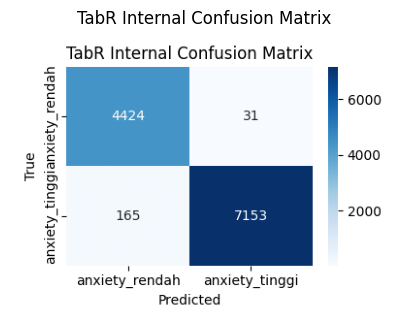

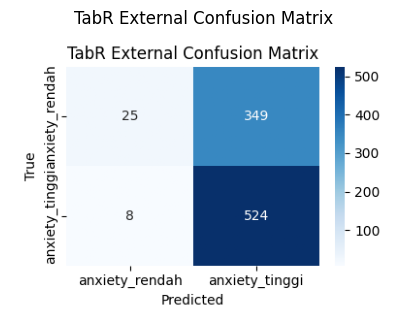


=== INTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score       support
0              0.964044  0.993042  0.978328   4455.000000
1              0.995685  0.977453  0.986485   7318.000000
accuracy       0.983352  0.983352  0.983352      0.983352
macro avg      0.979865  0.985247  0.982406  11773.000000
weighted avg   0.983712  0.983352  0.983398  11773.000000

=== EXTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score    support
0              0.757576  0.066845  0.122850  374.00000
1              0.600229  0.984962  0.745907  532.00000
accuracy       0.605960  0.605960  0.605960    0.60596
macro avg      0.678902  0.525904  0.434379  906.00000
weighted avg   0.665182  0.605960  0.488707  906.00000


In [12]:
visualize_results(OUT_DIR)


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t3/tabr_logs/version_0/metrics.csv


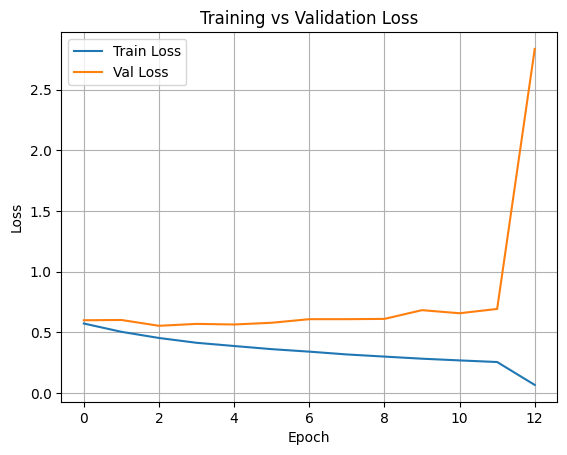

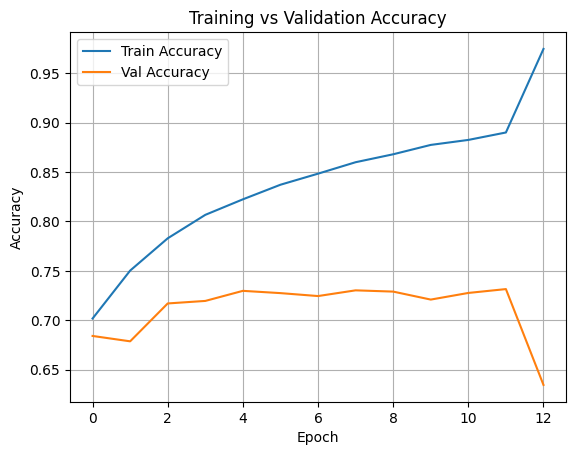

In [13]:
metrics_csv = sorted((OUT_DIR / 'tabr_logs').glob('version_*/metrics.csv'))[-1]
print(metrics_csv)
plot_lightning_metrics(metrics_csv)


In [14]:
print('Internal CM:')
print(results['internal']['cm'])
print('External CM:')
print(results['external']['cm'])


Internal CM:
[[4424   31]
 [ 165 7153]]
External CM:
[[ 25 349]
 [  8 524]]


In [15]:
external_event_table = event_table[event_table['event_id'].isin(external_event_ids)].sort_values(['label', 'phase', 'participant', 'question', 'clip', 'event_clip'], kind='stable')
external_event_table.head(50)


,event_id,label,target,phase,participant,question,clip,event_clip
1437,after||abdul_aziz||q1||answer_1_15d591ce-051a-...,anxiety_rendah,0,after,abdul_aziz,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00006-00024
1462,after||achmad_anfasa_rabbany||q1||answer_1_15d...,anxiety_rendah,0,after,achmad_anfasa_rabbany,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00044-00076
1511,after||ahmad_rifqi_hendriansyah||q1||answer_1_...,anxiety_rendah,0,after,ahmad_rifqi_hendriansyah,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00089-00094
1536,after||aida_rahma_fadhila||q1||answer_1_15d591...,anxiety_rendah,0,after,aida_rahma_fadhila,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00119-00135
1561,after||akhmad_aakhif_athallah||q1||answer_1_15...,anxiety_rendah,0,after,akhmad_aakhif_athallah,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00217-00239
1611,after||aryan_saputra_rahmad||q1||answer_1_15d5...,anxiety_rendah,0,after,aryan_saputra_rahmad,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00007-00018
1636,after||ashrul_rifki_ardiyhasa||q1||answer_1_15...,anxiety_rendah,0,after,ashrul_rifki_ardiyhasa,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00001-00021
1661,after||ayleen_ruhul_qisthy||q1||answer_1_15d59...,anxiety_rendah,0,after,ayleen_ruhul_qisthy,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00159-00195
1685,after||billy_maulana_ferdinan||q1||answer_1_15...,anxiety_rendah,0,after,billy_maulana_ferdinan,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00014-00026
1809,after||ericha_rizki_wardani||q1||answer_1_15d5...,anxiety_rendah,0,after,ericha_rizki_wardani,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00006-00013


In [16]:
print('=== ROW DISTRIBUTION ===')
print('train rows by label')
print(df_tr['label'].value_counts(dropna=False).sort_index())
print()
print('val rows by label')
print(df_val['label'].value_counts(dropna=False).sort_index())
print()
print('external rows by label')
print(df_external['label'].value_counts(dropna=False).sort_index())
print()
print('=== EVENT DISTRIBUTION ===')
print('train events by label')
print(df_tr[['event_id', 'label']].drop_duplicates()['label'].value_counts(dropna=False).sort_index())
print()
print('val events by label')
print(df_val[['event_id', 'label']].drop_duplicates()['label'].value_counts(dropna=False).sort_index())
print()
print('external events by label')
print(df_external[['event_id', 'label']].drop_duplicates()['label'].value_counts(dropna=False).sort_index())
print()
print('=== PHASE DISTRIBUTION ===')
print('train phase x label')
print(pd.crosstab(df_tr['phase'], df_tr['label']))
print()
print('val phase x label')
print(pd.crosstab(df_val['phase'], df_val['label']))
print()
print('external phase x label')
print(pd.crosstab(df_external['phase'], df_external['label']))
print()
print('=== PARTICIPANT DISTRIBUTION ===')
print('train unique participants by label')
print(df_tr.groupby('label')['participant'].nunique())
print()
print('val unique participants by label')
print(df_val.groupby('label')['participant'].nunique())
print()
print('external unique participants by label')
print(df_external.groupby('label')['participant'].nunique())


=== ROW DISTRIBUTION ===
train rows by label
label
anxiety_rendah    16847
anxiety_tinggi    28130
Name: count, dtype: int64

val rows by label
label
anxiety_rendah    4455
anxiety_tinggi    7318
Name: count, dtype: int64

external rows by label
label
anxiety_rendah    374
anxiety_tinggi    532
Name: count, dtype: int64

=== EVENT DISTRIBUTION ===
train events by label
label
anxiety_rendah     889
anxiety_tinggi    1289
Name: count, dtype: int64

val events by label
label
anxiety_rendah    223
anxiety_tinggi    322
Name: count, dtype: int64

external events by label
label
anxiety_rendah    20
anxiety_tinggi    20
Name: count, dtype: int64

=== PHASE DISTRIBUTION ===
train phase x label
label   anxiety_rendah  anxiety_tinggi
phase                                 
after            10681            9981
before            6166           18149

val phase x label
label   anxiety_rendah  anxiety_tinggi
phase                                 
after             3078            2520
before       